**Experiment 3: Implement the KNN algorithm for classification and demonstrate the process of finding out optimal  "K" value using Python Programming.**

**Aim:** To implement the K-Nearest Neighbors (KNN) algorithm for classification using Python and to determine the optimal value of **K** by evaluating model performance on a test dataset.

**Overview of K-Nearest Neighbors (KNN)**

**K-Nearest Neighbors (KNN)** is a **non-parametric, instance-based learning algorithm** used for **classification and regression**.
It predicts the output of a data point based on the **majority class (for classification)** or **average value (for regression)** of its **k nearest neighbors** in the feature space.

KNN works by:

* **Storing all training data**
* **Calculating distances** between a new data point and training points
* **Selecting the k closest points**
* **Predicting output** based on neighbor values

---

**Key Components**

**1. Distance Metric**

KNN relies on a distance metric to find neighbors. Common metrics:

* **Euclidean Distance (most common):**

d(x, y) = sqrt(sum((x_i - y_i)^2))

* **Manhattan Distance:**

d(x, y) = sum(abs(x_i - y_i))

Where (x_i, y_i) are feature values of points x and y.

---

**2. Number of Neighbors (k)**

* **k** determines how many nearest points influence the prediction.
* Small k → sensitive to noise
* Large k → smoother decision boundary

---

**3. Voting / Aggregation**

* **Classification:** majority vote of neighbors
* **Regression:** average (or weighted average) of neighbors

y_hat = (1/k) * sum(y_i for i = 1 to k)

---

**4. Feature Scaling**

Distance-based methods are sensitive to scale. Features are often **normalized or standardized**:

x' = (x - min(x)) / (max(x) - min(x))

---

**Key Terms**

**1. k (Neighbors)** – Number of closest points considered for prediction.

**2. Distance Metric** – Method to measure closeness between points (Euclidean, Manhattan, etc.).

**3. Instance-Based Learning** – KNN does not learn a model; it stores data and makes predictions on demand.

**4. Weighted KNN** – Neighbors closer to the query point have more influence.

**5. Non-Parametric** – KNN does not assume a specific form for the underlying data distribution.

**6. Curse of Dimensionality** – KNN performance drops in high-dimensional spaces because distances become less meaningful.


**Dataset Loading and Inspection**

We use the Wine dataset, where the first column is the class label and remaining columns are features.

In [59]:
import pandas as pd

wine_data = pd.read_csv('drive/MyDrive/Datasets For ML/wine.csv')

print("Columns:", wine_data.columns)
print("\nShape:", wine_data.shape)
print("\nDuplicated:", wine_data.duplicated().sum())
print("\nNull Values:", wine_data.isnull().sum().sum())
print("\nFirst 2 rows:")
wine_data.head(2)

Columns: Index(['Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'],
      dtype='object')

Shape: (178, 13)

Duplicated: 0

Null Values: 0

First 2 rows:


,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40


**Feature–Label Separation**

X → feature matrix

Y → class labels

In [60]:
X, Y = wine_data.iloc[:, 1:], wine_data.iloc[:, 0]

**Feature Scaling (Entire Dataset)**

KNN is distance-based. Scaling is required.

Features are scaled using StandardScaler to ensure fair distance computation.



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



wine_data_scaled = pd.DataFrame(X_scaled, columns=X.columns)

wine_data_scaled.head(2)

**Train–Test Split**

80% training data

20% testing data

Stratified split to preserve class distribution

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=5)

**Implementing KNN and Finding Optimal K**

We train KNN models with different K values and record accuracy.

The K with maximum accuracy is selected.

In [62]:
from sklearn.neighbors import KNeighborsClassifier

acc1 = []

for i in range(1, 11):
    temp = KNeighborsClassifier(n_neighbors=i, algorithm='ball_tree')
    temp.fit(X_train, Y_train)
    acc1.append(temp.score(X_test, Y_test))

print("Accuracy: ", acc1)

Accuracy:  [0.8888888888888888, 0.8055555555555556, 0.8888888888888888, 0.8055555555555556, 0.8333333333333334, 0.8055555555555556, 0.75, 0.7777777777777778, 0.8055555555555556, 0.7777777777777778]


**Simple Accuracy vs K Plot**

Single model. Clear.

The plot visualizes how K affects model performance.

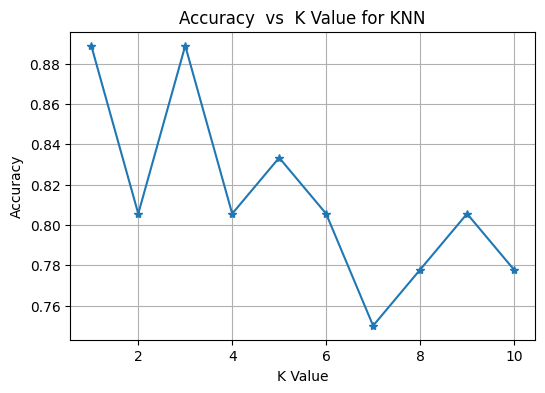

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), acc1, marker='*')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy  vs  K Value for KNN')
plt.grid(True)
plt.show()

In [64]:
acc2 = []

for i in range(1, 11):
    temp = KNeighborsClassifier(n_neighbors=i, weights='distance', algorithm='kd_tree',  metric='manhattan')
    temp.fit(X_train, Y_train)
    acc2.append(temp.score(X_test, Y_test))

print("Accuracy: ", acc2)

Accuracy:  [0.9166666666666666, 0.9166666666666666, 0.8611111111111112, 0.8888888888888888, 0.9166666666666666, 0.9444444444444444, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666, 0.9166666666666666]


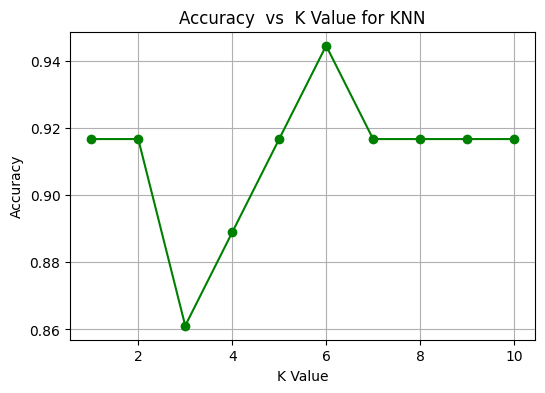

In [65]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), acc2, marker='o', color='green')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy  vs  K Value for KNN')
plt.grid(True)
plt.show()

**Training Final Model with Optimal K**

We use distance-weighted KNN to give closer neighbors more importance.

In [66]:
# Find best k for each setup
max_acc_1 = max(acc1)
max_k_1 = acc1.index(max_acc_1) + 1

max_acc_2 = max(acc2)
max_k_2 = acc2.index(max_acc_2) + 1

print("Max K 1:", max_k_1, ", Max Accuracy 1:", max_acc_1)
print("Max K 2:", max_k_2, ", Max Accuracy 2:", max_acc_2)

# Choose the better model
if max_acc_1 >= max_acc_2:
    optimal_k = max_k_1
    neigh = KNeighborsClassifier(n_neighbors=optimal_k)
else:
    optimal_k = max_k_2
    neigh = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance', algorithm='kd_tree', metric='manhattan')

print("\nOptimal K:", optimal_k)

# Correct fit call
neigh.fit(X_train, Y_train)

Max K 1: 1 , Max Accuracy 1: 0.8888888888888888
Max K 2: 6 , Max Accuracy 2: 0.9444444444444444

Optimal K: 6


KNeighborsClassifier(algorithm='kd_tree', metric='manhattan', n_neighbors=6,
                     weights='distance')

**Model Predictions and Neighbor Analysis**

a) Predict class labels

b) Predict probabilities

c) Find nearest neighbors for a sample

d) Neighbor graph

In [67]:
Y_pred = neigh.predict(X_test)
print("Predicted Labels For X_test:", Y_pred)

print("\nPredicted Probabilities:\n", neigh.predict_proba(X_test)[:10])

Predicted Labels For X_test: [3 1 2 2 1 3 3 1 1 3 1 3 2 1 1 2 3 3 2 3 2 2 2 2 1 2 1 2 3 2 1 1 3 1 1 1]

Predicted Probabilities:
 [[0.48510577 0.         0.51489423]
 [1.         0.         0.        ]
 [0.32434758 0.67565242 0.        ]
 [0.29602864 0.70397136 0.        ]
 [1.         0.         0.        ]
 [0.         0.33276858 0.66723142]
 [0.         0.         1.        ]
 [0.6915897  0.3084103  0.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]]


In [68]:
sample_data = pd.DataFrame([[13.10, 3.44, 2.15, 21.0, 102, 1.87, 0.55, 0.49, 1.30, 4.075600, 0.70, 0.68]], columns=X.columns)
# It is important to scale the sample data using the same scaler used for the training data
# sample_data_scaled = scaler.transform(sample_data)

print("Nearest Neighbors For A Sample:", neigh.kneighbors(sample_data))

print("\nNeighbor Graph:\n", neigh.kneighbors_graph(X_test)[:5])

Nearest Neighbors For A Sample: (array([[7.6444, 7.9844, 8.1916, 8.4344, 8.7344, 9.4556]]), array([[137,  10, 110,  37, 102, 139]]))

Neighbor Graph:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30 stored elements and shape (5, 142)>
  Coords	Values
  (0, 73)	1.0
  (0, 51)	1.0
  (0, 20)	1.0
  (0, 120)	1.0
  (0, 40)	1.0
  (0, 114)	1.0
  (1, 91)	1.0
  (1, 96)	1.0
  (1, 74)	1.0
  (1, 116)	1.0
  (1, 79)	1.0
  (1, 64)	1.0
  (2, 16)	1.0
  (2, 93)	1.0
  (2, 59)	1.0
  (2, 11)	1.0
  (2, 129)	1.0
  (2, 92)	1.0
  (3, 59)	1.0
  (3, 16)	1.0
  (3, 93)	1.0
  (3, 63)	1.0
  (3, 11)	1.0
  (3, 96)	1.0
  (4, 30)	1.0
  (4, 118)	1.0
  (4, 88)	1.0
  (4, 27)	1.0
  (4, 87)	1.0
  (4, 131)	1.0


**Exploring Model Parameters**

a) Get current parameters

b) Modify parameters

c) Metadata Routing Information

d) Model Accuracy

In [69]:
model_accuracy = neigh.score(X_test, Y_test)
print("Classification or Model Accuracy Before Modifying Parameters: ", model_accuracy)

Classification or Model Accuracy Before Modifying Parameters:  0.9444444444444444


In [70]:
params = neigh.get_params()
print("Current Parameters: ", params)

Current Parameters:  {'algorithm': 'kd_tree', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 6, 'p': 2, 'weights': 'distance'}


In [71]:
neigh.set_params(n_neighbors=3, weights='uniform', algorithm='ball_tree', metric='euclidean')
print("Modified Parameters: ", neigh.get_params())

Modified Parameters:  {'algorithm': 'ball_tree', 'leaf_size': 30, 'metric': 'euclidean', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}


In [72]:
routing = neigh.get_metadata_routing()
print("Metadata Routing Information: ", routing)

Metadata Routing Information:  {'score': {'sample_weight': None}}


In [73]:
model_accuracy = neigh.score(X_test, Y_test)
print("Classification or Model Accuracy: ", model_accuracy)

Classification or Model Accuracy:  0.8611111111111112


**Nearest Neighbors for All Test Samples:** Returns distances and indices of nearest neighbors for each test instance.

In [74]:
neigh.kneighbors(X_test)

(array([[10.65    , 12.04    , 13.11    ],
        [ 4.16    ,  6.      ,  7.73    ],
        [ 5.38    ,  5.52    ,  6.01    ],
        [ 5.25    ,  7.42    ,  8.22    ],
        [ 7.36    ,  8.67    , 15.64    ],
        [ 6.976   ,  7.04    ,  7.44    ],
        [ 4.330001,  7.709999,  8.449999],
        [ 6.65    ,  8.16    ,  8.94    ],
        [ 2.48    ,  3.76    ,  6.07    ],
        [ 5.15    ,  5.81    ,  5.94    ],
        [ 5.21    ,  7.97    ,  7.98    ],
        [10.8     , 11.99    , 14.84    ],
        [ 7.17    ,  7.41    ,  9.03    ],
        [ 4.25    ,  6.18    ,  6.42    ],
        [ 6.27    ,  7.49    ,  7.5     ],
        [ 4.34    ,  4.85    ,  5.54    ],
        [ 5.27    ,  5.35    ,  9.03    ],
        [ 3.84    ,  5.45    ,  6.95    ],
        [ 4.42    ,  6.8     ,  7.67    ],
        [ 5.44    ,  7.27    ,  7.76    ],
        [ 8.84    ,  8.87    ,  9.      ],
        [ 5.95    ,  6.45    ,  6.73    ],
        [21.79    , 22.52    , 22.95    ],
        [ 6

**Enabling Metadata Routing (Advanced Feature):** Metadata routing is disabled by default.
This step explicitly enables it for advanced experimentation.

In [75]:
from sklearn import set_config

set_config(enable_metadata_routing=True)
neigh.set_score_request()

KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_neighbors=3)

**Import Metrics Module**

**Listing Available Metrics:** Displays all metrics available in sklearn.

**Performance Evaluation Metrics:** We evaluate the model using standard classification metrics.

In [76]:
from sklearn import metrics

dir(metrics)

['ConfusionMatrixDisplay',
 'DetCurveDisplay',
 'DistanceMetric',
 'PrecisionRecallDisplay',
 'PredictionErrorDisplay',
 'RocCurveDisplay',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_classification',
 '_dist_metrics',
 '_pairwise_distances_reduction',
 '_pairwise_fast',
 '_plot',
 '_ranking',
 '_regression',
 '_scorer',
 'accuracy_score',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'auc',
 'average_precision_score',
 'balanced_accuracy_score',
 'brier_score_loss',
 'calinski_harabasz_score',
 'check_scoring',
 'class_likelihood_ratios',
 'classification_report',
 'cluster',
 'cohen_kappa_score',
 'completeness_score',
 'confusion_matrix',
 'consensus_score',
 'coverage_error',
 'd2_absolute_error_score',
 'd2_log_loss_score',
 'd2_pinball_score',
 'd2_tweedie_score',
 'davies_bouldin_score',
 'dcg_score',
 'det_curve',
 'euclidean_distances',
 'explained_variance_sco

In [77]:
print("Accuracy Score: ", metrics.accuracy_score(Y_test, Y_pred))
print("F1 Score: ", metrics.f1_score(Y_test, Y_pred, average='micro'))
print("Recall Score: ", metrics.recall_score(Y_test, Y_pred, average='micro'))
print("Precision Score: ", metrics.precision_score(Y_test, Y_pred, average='micro'))

Accuracy Score:  0.9444444444444444
F1 Score:  0.9444444444444444
Recall Score:  0.9444444444444444
Precision Score:  0.9444444444444444


**Classification Report:** Provides precision, recall, F1-score, and support for each class.

In [78]:
print("Classification Report:\n", metrics.classification_report(Y_test, Y_pred))

Classification Report:
               precision    recall  f1-score   support

           1       0.86      1.00      0.92        12
           2       1.00      0.86      0.92        14
           3       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



**Distance Computation (Euclidean):** Shows pairwise distances between test samples.

In [79]:
print("Euclidean Distances:\n", metrics.euclidean_distances(X_test))

Euclidean Distances:
 [[ 0.         22.49846661 19.25619381 ... 18.08342888  7.37726236
  19.79995455]
 [22.49846661  0.          5.79596411 ...  4.71470041 23.80607485
   6.02265722]
 [19.25619381  5.79596411  0.         ...  5.06379304 21.53912719
   8.88407564]
 ...
 [18.08342888  4.71470041  5.06379304 ...  0.         19.4492005
   4.50204398]
 [ 7.37726236 23.80607485 21.53912719 ... 19.4492005   0.
  19.78473149]
 [19.79995455  6.02265722  8.88407564 ...  4.50204398 19.78473149
   0.        ]]


**Confusion Matrix:** Shows correct and incorrect predictions per class.

In [80]:
print("Confusion Matrix:\n", metrics.confusion_matrix(Y_test, Y_pred))

Confusion Matrix:
 [[12  0  0]
 [ 2 12  0]
 [ 0  0 10]]


**Confusion Matrix Visualization**

Confusion Matrix Display:


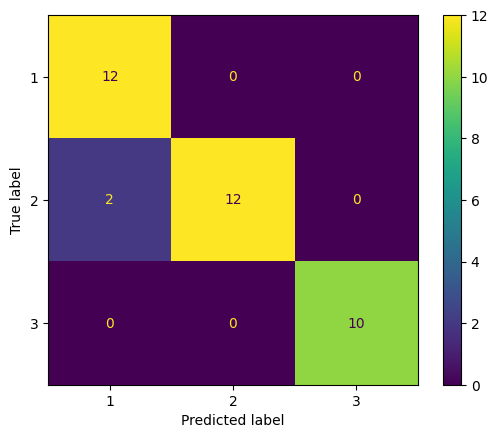

In [81]:
print("Confusion Matrix Display:")

metrics.ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)

**Conclusion**

KNN classifies data based on its nearest neighbors. Scaling features and choosing the right **k** are important. Using distance-weighted neighbors improves accuracy. Evaluation shows KNN works well when **k** and distance metric are properly selected.
